# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

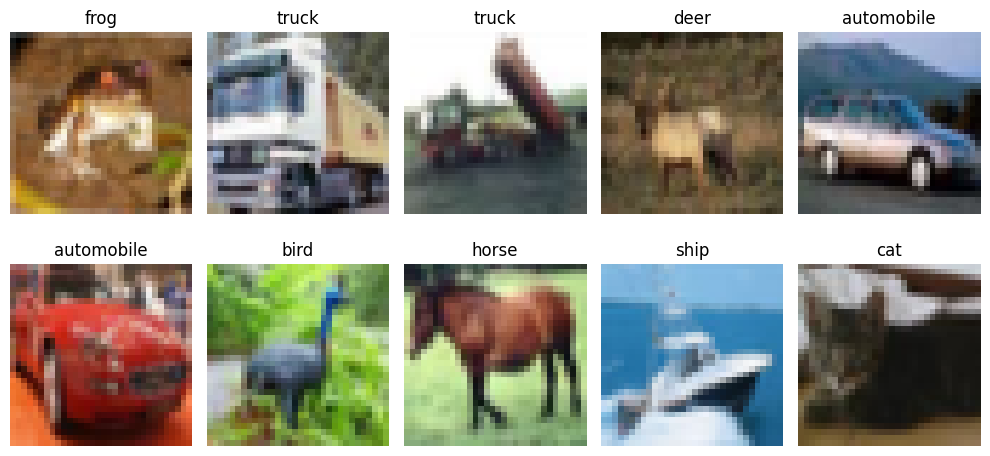

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
import gc
tf.keras.backend.clear_session()
gc.collect()

ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

d:\CODING FILES\Celebal Internship\week4\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.2726 - loss: 1.9888 - val_accuracy: 0.3336 - val_loss: 1.8195
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3187 - loss: 1.8629 - val_accuracy: 0.3470 - val_loss: 1.8142
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3378 - loss: 1.8102 - val_accuracy: 0.3800 - val_loss: 1.7343
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3504 - loss: 1.7732 - val_accuracy: 0.3880 - val_loss: 1.7388
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3672 - loss: 1.7393 - val_accuracy: 0.4102 - val_loss: 1.6736
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3661 - loss: 1.7446 - val_accuracy: 0.4096 - val_loss: 1.6975
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3802 - loss: 1.7129 - val_accuracy: 0.4142 - val_loss: 1.6731
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3814 - loss: 1.7013 - val_accu

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4354 - loss: 1.6241
ANN Test Accuracy: 0.43540000915527344


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
import gc
tf.keras.backend.clear_session()
gc.collect()

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

d:\CODING FILES\Celebal Internship\week4\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.4682 - loss: 1.4854 - val_accuracy: 0.5398 - val_loss: 1.2659
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.6143 - loss: 1.1105 - val_accuracy: 0.5534 - val_loss: 1.2687
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.6747 - loss: 0.9398 - val_accuracy: 0.6256 - val_loss: 1.0936
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.7163 - loss: 0.8178 - val_accuracy: 0.7114 - val_loss: 0.8570
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.7491 - loss: 0.7285 - val_accuracy: 0.6810 - val_loss: 0.9814
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.7686 - loss: 0.6573 - val_accuracy: 0.7132 - val_loss: 0.8532
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.7933 - loss: 0.5905 - val_accuracy: 0.6880 - val_loss: 0.9646
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.8148 - loss: 0.5286 - 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6949 - loss: 1.0221
CNN Test Accuracy: 0.6948999762535095


## 📈 Compare Learning Curves

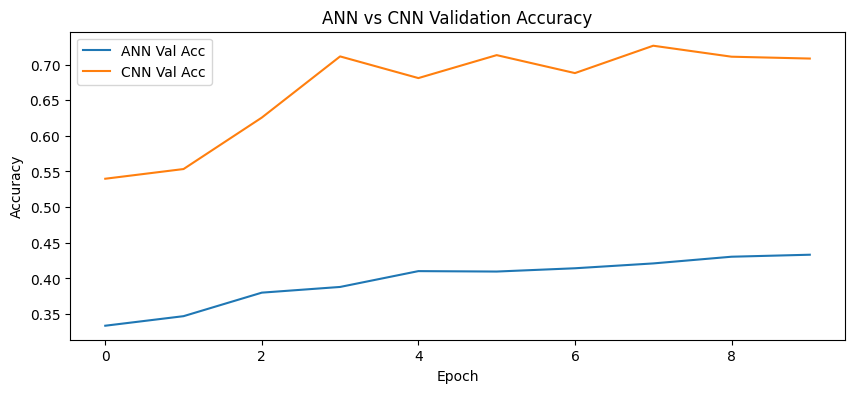

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
import gc
tf.keras.backend.clear_session()
gc.collect()

import gc
tf.keras.backend.clear_session()
gc.collect()

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.3559 - loss: 1.7663 - val_accuracy: 0.4642 - val_loss: 1.4831
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4506 - loss: 1.5194 - val_accuracy: 0.4632 - val_loss: 1.5342
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4919 - loss: 1.4140 - val_accuracy: 0.5654 - val_loss: 1.2030
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5238 - loss: 1.3458 - val_accuracy: 0.5978 - val_loss: 1.1288
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5396 - loss: 1.3036 - val_accuracy: 0.5860 - val_loss: 1.1423
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5507 - loss: 1.2698 - val_accuracy: 0.6272 - val_loss: 1.0540
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5592 - loss: 1.2469 - val_accuracy: 0.6274 - val_loss: 1.0533
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5727 - loss: 1.2162 - 

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})
comparison


,Model,Test Accuracy
0,ANN,0.4354
1,CNN,0.6949
2,Augmented CNN,0.6468


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# Solutions to Student Learning Tasks

Below, we implement the 5 beginner tasks to analyze and compare different deep learning architectures and training strategies on CIFAR-10.

### Task 1: Increase ANN layers and observe performance
We will design a deeper ANN model (`ann_model_deep`) with 4 dense layers: 512 -> 256 -> 128 -> 64. We will train it and observe if adding layers improves generalization or causes overfitting.

In [12]:
import gc
tf.keras.backend.clear_session()
gc.collect()

ann_model_deep = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_deep_history = ann_model_deep.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_deep_test_loss, ann_deep_test_acc = ann_model_deep.evaluate(x_test_flat, y_test)
print("Deep ANN Test Accuracy:", ann_deep_test_acc)

d:\CODING FILES\Celebal Internship\week4\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.2123 - loss: 2.0863 - val_accuracy: 0.2946 - val_loss: 1.9076
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.2822 - loss: 1.9394 - val_accuracy: 0.3278 - val_loss: 1.8868
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.2922 - loss: 1.9080 - val_accuracy: 0.3248 - val_loss: 1.8540
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3062 - loss: 1.8742 - val_accuracy: 0.3596 - val_loss: 1.8013
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3241 - loss: 1.8472 - val_accuracy: 0.3502 - val_loss: 1.8220
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3290 - loss: 1.8340 - val_accuracy: 0.3628 - val_loss: 1.8100
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.3362 - loss: 1.8172 - val_accuracy: 0.3808 - val_loss: 1.7710
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.3400 - loss: 1.8140 - val_acc

### Task 2: Change CNN filters
Since the baseline CNN in the notebook already uses 32 -> 64 -> 128 filters, we will create an alternative CNN configuration with larger filters (64 -> 128 -> 256) to see if widening the channels helps extract richer visual features and improves test accuracy.

In [13]:
import gc
tf.keras.backend.clear_session()
gc.collect()

cnn_model_wide = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_wide.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_wide_history = cnn_model_wide.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

cnn_wide_test_loss, cnn_wide_test_acc = cnn_model_wide.evaluate(x_test_norm, y_test)
print("Wide CNN Test Accuracy:", cnn_wide_test_acc)

d:\CODING FILES\Celebal Internship\week4\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 46ms/step - accuracy: 0.4287 - loss: 1.5840 - val_accuracy: 0.4762 - val_loss: 1.4726
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.5889 - loss: 1.1804 - val_accuracy: 0.5438 - val_loss: 1.3032
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.6655 - loss: 0.9639 - val_accuracy: 0.5784 - val_loss: 1.3464
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.7108 - loss: 0.8305 - val_accuracy: 0.5538 - val_loss: 1.3642
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.7530 - loss: 0.7124 - val_accuracy: 0.6880 - val_loss: 0.9403
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - accuracy: 0.7854 - loss: 0.6156 - val_accuracy: 0.7094 - val_loss: 0.9071
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.8132 - loss: 0.5352 - val_accuracy: 0.7244 - val_loss: 0.8495
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.8397 - loss: 0.4542 - 

### Tasks 3 & 4: Increase epochs to 20 & Add EarlyStopping
To check if longer training can improve results without overfitting, we will train a baseline CNN for up to 20 epochs using the `EarlyStopping` callback. This will automatically halt training when the validation loss stops improving for 3 consecutive epochs (`patience=3`) and restore the best weights.

In [14]:
import gc
tf.keras.backend.clear_session()
gc.collect()

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_model_es = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_es_history = cnn_model_es.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

cnn_es_test_loss, cnn_es_test_acc = cnn_model_es.evaluate(x_test_norm, y_test)
print("CNN with EarlyStopping Test Accuracy:", cnn_es_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.4714 - loss: 1.4909 - val_accuracy: 0.4030 - val_loss: 1.7659
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.6128 - loss: 1.1046 - val_accuracy: 0.6376 - val_loss: 1.0437
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.6752 - loss: 0.9317 - val_accuracy: 0.6040 - val_loss: 1.1649
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7169 - loss: 0.8134 - val_accuracy: 0.6462 - val_loss: 1.0591
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7466 - loss: 0.7261 - val_accuracy: 0.6586 - val_loss: 1.0271
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7728 - loss: 0.6449 - val_accuracy: 0.6462 - val_loss: 1.1827
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7976 - loss: 0.5769 - val_accuracy: 0.6690 - val_loss: 1.0644
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8170 - loss: 0.5141 - 

### Task 5: Add data augmentation training
We already trained the augmented CNN model (`aug_cnn_model`) in the section above. Let's summarize and compare the validation and test performances of all models.

### Overall Comparison Table (All Experiments)
Let's create an updated comparison table featuring the baseline models and the student task experiments.

In [15]:
results_data = {
    "Model": [
        "Baseline ANN", 
        "Deep ANN (Task 1)", 
        "Baseline CNN", 
        "Wide CNN (Task 2)", 
        "CNN + EarlyStopping (Tasks 3/4)", 
        "Augmented CNN (Task 5)"
    ],
    "Test Accuracy": [
        ann_test_acc, 
        ann_deep_test_acc, 
        cnn_test_acc, 
        cnn_wide_test_acc, 
        cnn_es_test_acc, 
        aug_test_acc
    ]
}
comparison_all = pd.DataFrame(results_data)
comparison_all

,Model,Test Accuracy
0,Baseline ANN,0.4354
1,Deep ANN (Task 1),0.3998
2,Baseline CNN,0.6949
3,Wide CNN (Task 2),0.7447
4,CNN + EarlyStopping (Tasks 3/4),0.6483
5,Augmented CNN (Task 5),0.6468


### Learning Curves Comparison
Let's plot the validation accuracy for all trained models to see how the learning dynamics compare.

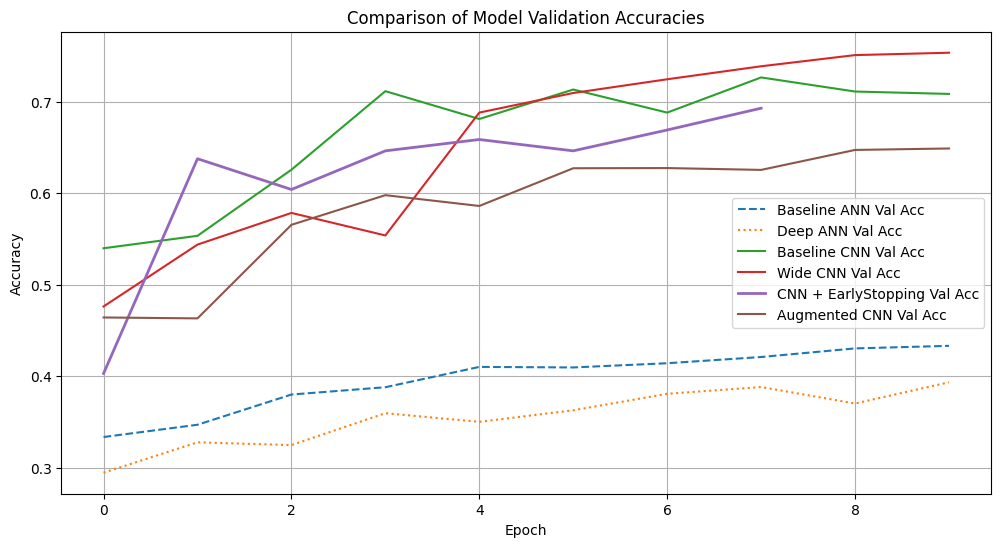

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(ann_history.history['val_accuracy'], label='Baseline ANN Val Acc', linestyle='--')
plt.plot(ann_deep_history.history['val_accuracy'], label='Deep ANN Val Acc', linestyle=':')
plt.plot(cnn_history.history['val_accuracy'], label='Baseline CNN Val Acc')
plt.plot(cnn_wide_history.history['val_accuracy'], label='Wide CNN Val Acc')
plt.plot(cnn_es_history.history['val_accuracy'], label='CNN + EarlyStopping Val Acc', linewidth=2)
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Comparison of Model Validation Accuracies")
plt.legend()
plt.grid(True)
plt.show()

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**